In [1]:
# Fix TF/protobuf crash in this environment:
# Force protobuf to use the Python implementation BEFORE importing TensorFlow.
import os

os.environ.setdefault("PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION", "python")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import tensorflow as tf
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau,
    EarlyStopping,
    ModelCheckpoint,
    TensorBoard,
)

seed = 4529
np.random.seed(seed)
tf.random.set_seed(seed)

print("TF version:", tf.__version__)
print(
    "Listing /kaggle/input (if exists):",
    os.listdir("/kaggle/input") if os.path.exists("/kaggle/input") else "N/A",
)



2026-01-10 20:26:42.204014: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768076802.217191      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768076802.221241      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TF version: 2.18.0
Listing /kaggle/input (if exists): ['sample_submission.csv', 'description.md', 'test.zip', 'train.csv', 'sample_submission.csv.zip', 'test', 'train.zip', 'aerial-cactus-identification', 'train', 'train.csv.zip']


In [2]:
CANDIDATE_ROOTS = [
    "/kaggle/input/aerial-cactus-identification",
    "/kaggle/data/aerial-cactus-identification",
    "../input/aerial-cactus-identification",
    "../data/aerial-cactus-identification",
    "/kaggle/input",
    "../input",
]

base_dir = None
for p in CANDIDATE_ROOTS:
    if os.path.exists(os.path.join(p, "train.csv")) and (
        os.path.isdir(os.path.join(p, "train"))
        or os.path.isdir(os.path.join(p, "train", "train"))
    ):
        base_dir = p
        break

if base_dir is None:
    base_dir = os.path.join("..", "input")

print("Using base_dir:", base_dir)


def resolve_image_dir(root, split):
    """
    Some provided directory listings show nested 'train/train' and 'test/test'.
    This resolver prefers the non-nested folder if present and contains jpgs.
    """
    direct = os.path.join(root, split)
    nested = os.path.join(root, split, split)

    def has_jpgs(d):
        if not os.path.isdir(d):
            return False
        try:
            for fn in os.listdir(d):
                if fn.lower().endswith(".jpg"):
                    return True
        except Exception:
            return False
        return False

    if has_jpgs(direct):
        return direct
    if has_jpgs(nested):
        return nested
    # Fallback: return whichever exists
    if os.path.isdir(direct):
        return direct
    if os.path.isdir(nested):
        return nested
    return direct


train_dir = resolve_image_dir(base_dir, "train")
test_dir = resolve_image_dir(base_dir, "test")

train_csv_path = os.path.join(base_dir, "train.csv")
sample_sub_path = os.path.join(base_dir, "sample_submission.csv")

train_df = pd.read_csv(train_csv_path)
print(train_df.head())
print("train_dir:", train_dir)
print("test_dir:", test_dir)
print("n_train:", len(train_df))

# Sanity checks
assert {"id", "has_cactus"}.issubset(
    train_df.columns
), "train.csv missing required columns"
assert os.path.isdir(train_dir), f"Train dir not found: {train_dir}"
assert os.path.isdir(test_dir), f"Test dir not found: {test_dir}"



Using base_dir: /kaggle/input/aerial-cactus-identification
                                     id  has_cactus
0  2de8f189f1dce439766637e75df0ee27.jpg           1
1  36704d250f236238e7f996812c48235d.jpg           1
2  eacde22fdc8c175972a5768e3daa8bc9.jpg           1
3  5d442f834da5e57d22b24802c32a8ca8.jpg           1
4  152491e0daf75c0e669400300ff7e645.jpg           1
train_dir: /kaggle/input/aerial-cactus-identification/train
test_dir: /kaggle/input/aerial-cactus-identification/test
n_train: 14175


In [3]:
# (kept core logic) Use ImageDataGenerator with validation split.
train_df["has_cactus"] = train_df["has_cactus"].astype(str)

batch_size = 64
# Keep original constants but guard against mismatch with generator length.
train_size = 15750
validation_size = 1750

datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    horizontal_flip=True,
    vertical_flip=False,
    validation_split=0.1,
)

data_args = {
    "dataframe": train_df,
    "directory": train_dir,
    "x_col": "id",
    "y_col": "has_cactus",
    "shuffle": True,
    "target_size": (32, 32),
    "batch_size": batch_size,
    "class_mode": "binary",
}

train_generator = datagen.flow_from_dataframe(**data_args, subset="training")
validation_generator = datagen.flow_from_dataframe(**data_args, subset="validation")

# Make steps consistent with actual generator sizes to avoid empty/partial epoch issues.
steps_per_epoch = min(train_size // batch_size, len(train_generator))
validation_steps = min(validation_size // batch_size, len(validation_generator))
steps_per_epoch = max(1, steps_per_epoch)
validation_steps = max(1, validation_steps)

print("steps_per_epoch:", steps_per_epoch, "validation_steps:", validation_steps)



Found 12758 validated image filenames belonging to 2 classes.
Found 1417 validated image filenames belonging to 2 classes.
steps_per_epoch: 200 validation_steps: 23


In [4]:
model = Sequential(
    [
        Conv2D(128, (3, 3), activation="relu", input_shape=(32, 32, 3)),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.2),
        Conv2D(64, (3, 3), activation="relu"),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.2),
        Flatten(),
        Dense(units=256, activation="relu"),
        Dropout(0.4),
        Dense(units=256, activation="relu"),
        Dropout(0.4),
        Dense(units=1, activation="sigmoid"),
    ]
)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["acc"],
)
model.summary()



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1768076809.760985      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:86:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739,329 (2.82 MB)

 Trainable params: 738,561 (2.82 MB)

 Non-trainable params: 768 (3.00 KB)

In [5]:
# Fix Keras 3 ModelCheckpoint requirement: filepath must end with .keras or .h5
ckpt_path = "aerial_cactus_detection.keras"

earlystop = EarlyStopping(
    monitor="val_acc", patience=10, verbose=1, restore_best_weights=False
)
reducelr = ReduceLROnPlateau(
    monitor="val_acc", factor=0.5, patience=3, verbose=1, min_lr=1e-6
)
modelckpt_cb = ModelCheckpoint(
    ckpt_path, monitor="val_acc", verbose=1, save_best_only=True, mode="max"
)
tb = TensorBoard(log_dir="logs")

callbacks = [earlystop, reducelr, modelckpt_cb, tb]
print("Callbacks configured. Checkpoint path:", ckpt_path)



Callbacks configured. Checkpoint path: aerial_cactus_detection.keras


In [6]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    epochs=30,
    verbose=1,
    shuffle=True,
    callbacks=callbacks,
)



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1768076813.730353      63 service.cc:148] XLA service 0x7f393c003b80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768076813.730383      63 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
I0000 00:00:1768076814.040969      63 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1768076816.810907      63 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


198/200 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - acc: 0.9106 - loss: 0.2580

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_acc improved from -inf to 0.24206, saving model to aerial_cactus_detection.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - acc: 0.9111 - loss: 0.2566 - val_acc: 0.2421 - val_loss: 4.3614 - learning_rate: 0.0010
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9680 - loss: 0.0865
Epoch 2: val_acc improved from 0.24206 to 0.29358, saving model to aerial_cactus_detection.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - acc: 0.9680 - loss: 0.0865 - val_acc: 0.2936 - val_loss: 2.7535 - learning_rate: 0.0010
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9788 - loss: 0.0593
Epoch 3: val_acc improved from 0.29358 to 0.97248, saving model to aerial_cactus_detection.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - acc: 0.9788 - loss: 0.0593 - val_acc: 0.9725 - val_loss: 0.0759 - learning_rate: 0.0010
Epoch 4/30
198/200 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9865 - loss: 0.0403
Epoch 4: val_acc did not improve from 0.97248
200/200 ━━━━━━━━━━━━━━

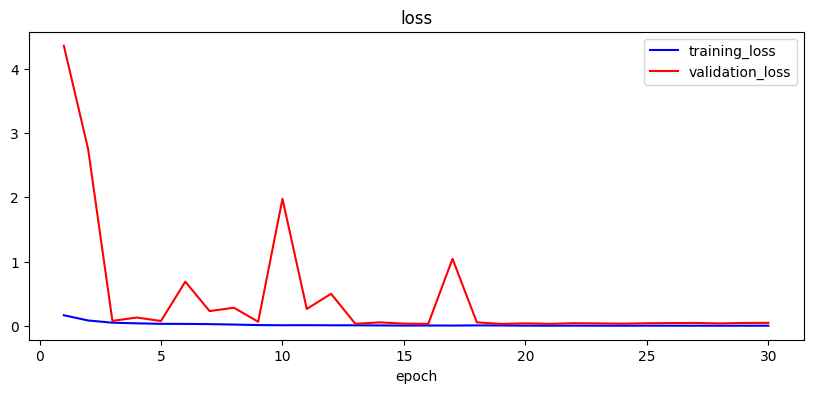

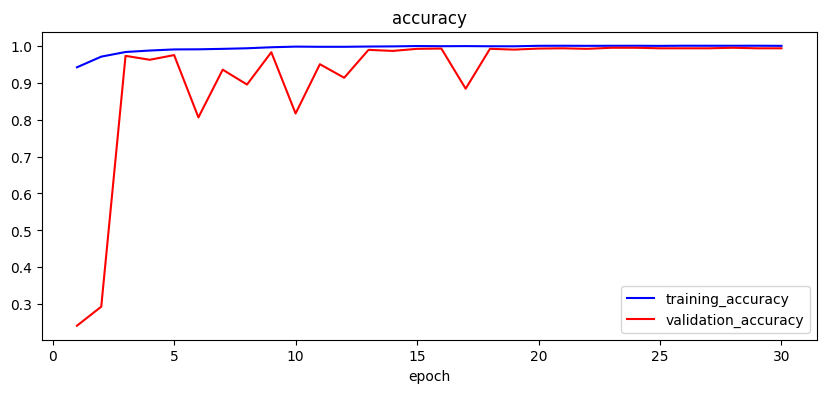

In [7]:
# Plotting (kept) but tolerant to metric key naming differences.
epochs = [i for i in range(1, len(history.history["loss"]) + 1)]

plt.figure(figsize=(10, 4))
plt.plot(epochs, history.history["loss"], color="blue", label="training_loss")
plt.plot(epochs, history.history["val_loss"], color="red", label="validation_loss")
plt.legend(loc="best")
plt.title("loss")
plt.xlabel("epoch")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(
    epochs, history.history.get("acc", []), color="blue", label="training_accuracy"
)
plt.plot(
    epochs, history.history.get("val_acc", []), color="red", label="validation_accuracy"
)
plt.legend(loc="best")
plt.title("accuracy")
plt.xlabel("epoch")
plt.show()



In [8]:
# Use a generator for test to avoid path bugs and ensure non-empty input to predict().
test_df = pd.read_csv(sample_sub_path)
print(test_df.head())
assert "id" in test_df.columns, "sample_submission.csv missing id column"

test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=test_dir,
    x_col="id",
    y_col=None,
    target_size=(32, 32),
    batch_size=256,
    shuffle=False,
    class_mode=None,
)

print("Test generator batches:", len(test_generator), "n_test:", test_generator.n)



                                     id  has_cactus
0  09034a34de0e2015a8a28dfe18f423f6.jpg         0.5
1  134f04305c795d6d202502c2ce3578f3.jpg         0.5
2  41fad8d145e6c41868ce3617e30a2545.jpg         0.5
3  35f8a11352c8d41b6231bb33d8d09f7e.jpg         0.5
4  b77dc902b035887cbbc01920ce0e3151.jpg         0.5
Found 3325 validated image filenames.
Test generator batches: 13 n_test: 3325


In [9]:
# Predict and write submission in required format.
pred = model.predict(test_generator, verbose=1)
pred = pred.reshape(-1).astype(np.float32)

# Guard length alignment
if len(pred) != len(test_df):
    # If generator drops remainder for any reason, truncate to the min length safely
    n = min(len(pred), len(test_df))
    pred = pred[:n]
    test_df = test_df.iloc[:n].copy()

test_df["has_cactus"] = pred
sub_path = "submission.csv"
test_df[["id", "has_cactus"]].to_csv(sub_path, index=False)

print("Wrote", sub_path, "with shape:", test_df.shape)
print(test_df.head())

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 197ms/step
Wrote submission.csv with shape: (3325, 2)
                                     id  has_cactus
0  09034a34de0e2015a8a28dfe18f423f6.jpg         1.0
1  134f04305c795d6d202502c2ce3578f3.jpg         1.0
2  41fad8d145e6c41868ce3617e30a2545.jpg         1.0
3  35f8a11352c8d41b6231bb33d8d09f7e.jpg         1.0
4  b77dc902b035887cbbc01920ce0e3151.jpg         1.0
